# Autograd

This is my (bad) implementation of Autograd. My goal for this project was to get really familiar with how backprop works and be able to implement it myself. While the project was largely inspired by Karpathy's micrograd project (https://github.com/karpathy/micrograd), I didn't actually watch/read his implementation and opted to try to work through it myself with some help from an AI. My code is definitely not optimal or nice to use, but it is functional which is what I was going for. 

### Automatic Differentiation (AD)
Automatic Differentiation is "...a set of techniques to evaluate the partial derivative of a function specified by a computer program" (https://en.wikipedia.org/wiki/Automatic_differentiation ). This is exactly what we need to do when we are calculating the gradients in gradient descend. 

There are two main types of AD:
- **Forward Accumulation**: Where we perturbe the input and see how it affects the output.
    - This method's runtime is based on the number of inputs and the overall complexity of the function (neural network) 
- **Reverse Accumulation**: Where we start at the output and see how it gets affected by the previous function 
    - Run time is proportional to number of outputs and the complexity of the function's calculations

Since when calculating the loss in gradient descent our output is usually a scalar (MSE, BCE, etc.) reverse accumulation makes much more sense. My intuition around this is that in forward mode we have to go through the network fully for every single weight (real slow) but for backprop we calculate the "sensitivity" of each layer that could be used in the calculations for the derivatives of the nodes in the previous layer, so we efficiently re-use our calculations.

As a side note, true AD is neither symbolic (solving derivatives by manipulating variables e.g. $\frac{dx^2}{dx}= 2x$) nor numeric (using the limit definition of a derivative to approximate the derivative). 

#### Example 
*This example was AI generated when I was trying to understand the differences between the two methods.*

Say we have a small nested function where $a = x_1 \cdot x_2$ and $y=a+x_1$ and we want to find the partial derivatives of $x_1,x_2$ w.r.t. $y$ at $x_1=2, x_2=3$. The function/network could be written as $f(x_1,x_2)=y(a(x_1,x_2),x_1)$ 
- With forward accumulation this would look like this:
    - Perturbe $x_1$ i.e. $\Delta x_1=1$
    - Then we see how $a$ changes: $\Delta a = (\Delta x_1 \cdot x_2) + (x_1 \cdot \Delta x_2) = (1\cdot 3) + (2 \cdot 0) = 3$ (by the chain rule for multivariable functions and since we don't perturbe $x_2$ we have $\Delta x_2=0$)
    - Now we check how $y$ would change: $\Delta y = \Delta a + \Delta x_1 = 3+1 =4$
    - So we get that $\frac{\partial y}{\partial x_1}=4$. Now we would repeat the same steps for $x_2$
- With reverse accumulation:
    - We check how much each step affects the output. For $y=a+x_1$ we have:
        - $\frac{\partial y}{\partial a}=\bar{a} = 1$
        - $\frac{\partial y}{\partial x_1}= \bar{x_1} = 1$
    - Next we see how the inputs affect $a$:
        - $\bar{x_2} = \bar{a} \cdot x_1 = 1 \cdot 2 = 2$
        - $\bar{x_1} = \bar{x_1} + (\bar{a}\cdot x_2)= 1 + 3 = 4$. The extra addition of $\bar{x_1}$ is there because it not only affects $y$ through changing $a$ but it also affects it directly.
    - So we obtain that $\nabla f(x_1,x_2) = (4,2)$

The example might not be the clearest thing ever, but the general idea is that we are using the chain rule and calculating the total derivative either starting from the input or from the output. Also when doing reverse accumulation we frequently need intermediate values that we get when doing a forward pass, so it's not just a single backwards pass process. 

### Implementation
For this project we will create a very sub-optimal, scalar-only version of autograd. To do so we will utilize a Node class which is designed to act like a regular numeric value while keeping some additional information about how it got calculated and its derivative rules. The object stores the value of the number, the gradient, the operation that was used to derive the object (e.g. a product or a sum), and the parent Nodes of the object if it was derived from other values. In addition, this object has methods for handling different operations that create new nodes and link it to the orginal ones, allowing us to create a Directed Acyclic Graph (DAG). Lastly, the object has rules for how to calculate the gradients according to which operation was used to derive the number and a function that creates a topological sort and iterates through all the gradient calculations.

A crucial aspect of the implementation is the DAG. This graph allows us to go from the loss function and calculate the gradient for each parent node iteratively. There will be a visual below to demonstrate this and make the idea clearer. I am not explaining this too well, but hopefully the main message of a need for a graph structure is getting through. 

Additionally, when we go "backwards" through the graph we can't do it in any random order. Doing a recursion that calls the `_backprop()` on parents of every node can result in us double calling that function on some node and inflating the gradients. Instead we use a topological sort which allows us to call the function only once on each node and have the logical order of which nodes affect which ones (not the best explanation either...). 

In [13]:
import numpy as np
from matplotlib import pyplot as plt 
from sklearn.model_selection import train_test_split
rng = np.random.default_rng(seed=42)

In [2]:
class Node:
    def __init__(self, val, parents=[], operation=""):
        self.val = val
        self.parents = parents
        self.gradient = 0.0
        self.operation = operation

    def __add__(self, other_node):
        if type(other_node) != Node:
            other_node = Node(other_node)
        new_node = Node(self.val + other_node.val, parents=[self,other_node],operation="+")
        return new_node

    def __mul__(self, other_node):
        if type(other_node) != Node:
            other_node = Node(other_node)
        new_node = Node(self.val * other_node.val, parents=[self,other_node],operation="*")
        return new_node

    def log(self):
        return Node(np.log(self.val),parents=[self], operation="log")

    def relu(self):
        return Node(max(0,self.val),parents=[self], operation="relu")

    def sigmoid(self):
        new_val = 1/(1+np.exp(-self.val))
        return Node(new_val,parents=[self], operation="sigmoid")

    def _backprop(self):
        if not self.parents:
            pass
        elif self.operation == "+":
            self.parents[0].gradient += self.gradient
            self.parents[1].gradient += self.gradient
        elif self.operation == "*":
            self.parents[0].gradient += self.gradient * self.parents[1].val
            self.parents[1].gradient += self.gradient * self.parents[0].val
        elif self.operation == "relu":
            self.parents[0].gradient += 0 if self.val <= 0 else self.gradient
        elif self.operation == "sigmoid":
            sigmoid_dx = self.val * (1-self.val)
            self.parents[0].gradient += self.gradient * sigmoid_dx
        elif self.operation == "log":
            if self.parents[0] == 0:
                print("Adding epsilon to prevent division by 0")
                self.parents[0] += 1e-5
            self.parents[0].gradient += self.gradient / self.parents[0].val 
    
    # This code was AI generated, I didn't really feel like implementing a topological sort
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for p in v.parents:
                    build_topo(p)
                topo.append(v)
        build_topo(self)
    
        self.gradient = 1.0
        for node in reversed(topo):
            node._backprop() 
            


### Visual
Let's visualize what we created. 

The visualization code below is AI generated and it told me that it was based on Karpathy's Micrograd. I don't even know how to give credit here. 

In [3]:
from graphviz import Digraph

def trace(root):
    # Builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.parents:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # Left to Right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # Draw the value node
        dot.node(name=uid, label="{ data %.4f | grad %.4f }" % (n.val, n.gradient), shape='record')
        if n.operation:
            # Draw the operation node
            dot.node(name=uid + n.operation, label=n.operation)
            dot.edge(uid + n.operation, uid)
            
    for n1, n2 in edges:
        # Connect nodes to their operation nodes
        dot.edge(str(id(n1)), str(id(n2)) + n2.operation)
        
    return dot

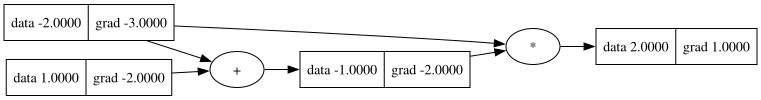

In [4]:
x = Node(1)
y = Node(-2)
c = x + y
z = y*c
z.gradient = 1
z.backward()

draw_dot(z)

Alright. The numbers are correct and the graph tells us the story of how the equations are set up. Now it is time to create a Neural Network and see if we can use the AD algorithm for backprop!

### Neural Network
Since we need to use the Node class for every single parameter in the network I can't really rely on NumPy matrices to have nice and efficient code any more (there might be a way with a custom `dtype` but I didn't really look into this too hard). To do we need to break down the Network into a bunch of scalar operations and for-loops. 

The code below does not use best practices and is quite... frail. Most of the issues arise because when we try to add non-Nodes with Nodes. But this version does work fairly ok and we can quickly modify the architecture of the network without any issues.

As a side note, we use SGD here because it was easier to program it that way. 

In [5]:
class Neuron:
    def __init__(self, in_dim, activation = "relu"):
        self.weight = [Node(rng.random()) for _ in range(in_dim)]
        self.bias = Node(rng.random())
        self.activation = activation

    def _lin_sum(self, x):
        s = Node(0)
        for i in range(len(x)):
            s += self.weight[i]* x[i] 
        return s + self.bias

    def _activate(self,x):
        if self.activation == "relu":
            return x.relu()
        elif self.activation == "sigmoid":
            return x.sigmoid()

    def forward(self, x):
        z = self._lin_sum(x)
        a = self._activate(z)
        return a
            

class Layer:
    def __init__(self, in_dim, out_dim, activation="relu"):
        self.Neurons = [Neuron(in_dim, activation=activation) for _ in range(out_dim)]

    def forward(self,x):
        output = []
        for i in range(len(self.Neurons)):
            output.append(self.Neurons[i].forward(x))
        return output 

class NeuralNetwork:
    def __init__(self, neurons_per_layer, activations, input_dim = 2):
        self.loss_history = []
        self.Layers = []
        in_d = input_dim
        for i in range(len(neurons_per_layer)):
            out_d = neurons_per_layer[i] 
            self.Layers.append(Layer(in_d,out_d, activation=activations[i]))
            in_d = neurons_per_layer[i]
    
    def forward(self,x):
        for layer in self.Layers:
            x = layer.forward(x)
        return x[-1]

    def calculate_loss(self, y_pred, y_true):
        if not isinstance(y_true, Node):
            y_true = Node(y_true)
        left_side = y_true * y_pred.log()
        temp = Node(1) + y_pred * Node(-1)
        right_side = (Node(1) + y_true * Node(-1)) * temp.log()
        total = Node(-1) * (left_side+right_side)
        return total

    def get_params(self):
        output = []
        for layer in self.Layers:
            for neuron in layer.Neurons:
                for weight in neuron.weight:
                    output.append(weight)
                output.append(neuron.bias)

        return output

    def train(self, X, Y, epochs = 10, a=0.01):
        for _ in range(epochs):
            for i in range(len(X)):
                y_pred = self.forward(X[i])
                loss = self.calculate_loss(y_pred,Y[i])
                self.loss_history.append(loss.val)
                loss.gradient = 1
                loss.backward()
                params = self.get_params()
                for param in params:
                    param.val -= a * param.gradient
                    param.gradient = 0        # don't forget to zero out the gradients
                


### XOR Problem
Just like in my MLP notebook we will see if we can ace the XOR problem. 

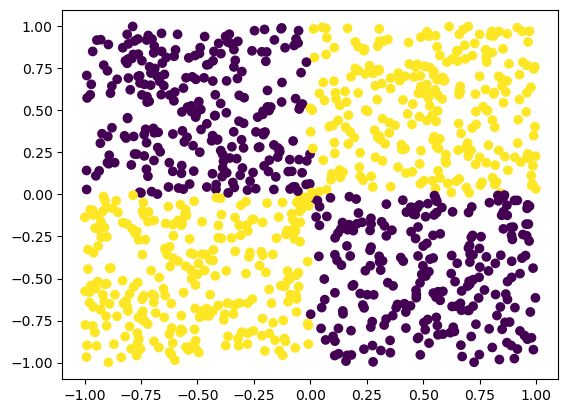

In [6]:
N = 1000
X = rng.uniform(-1,1,(N,2))
Y = np.zeros((N,1))
Y[X[:,0] * X[:,1] > 0] = 1

plt.scatter(X[:,0],X[:,1], c=Y)

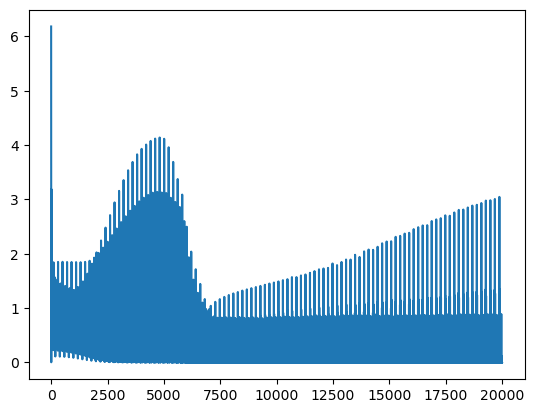

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.8)

NN = NeuralNetwork([8,4,1], activations = ["relu","relu","sigmoid"])
NN.train(X_train, Y_train, a=0.01, epochs = 100)

plt.plot(NN.loss_history)

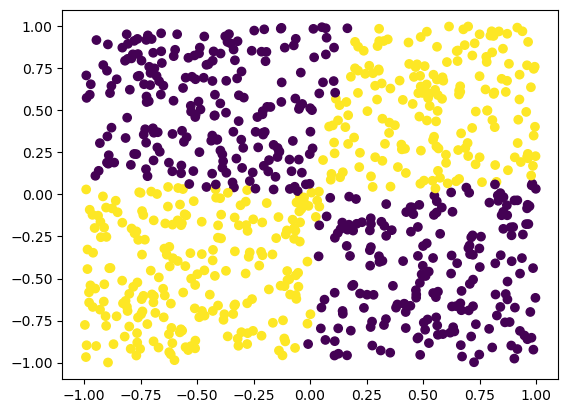

In [12]:
predictions = [np.round(NN.forward(X_test[i]).val) for i in range(len(Y_test))]
plt.scatter(X_test[:,0],X_test[:,1], c=predictions)

Awesome, looks like the model is fairly functional! 

This was a very educational notebook for me and really helped me to build a mental map of the resources that are used in training Neural Networks as well as how backprop really works. Hope this notebook could be of some help to anyone who got this far!